Hyper parameter Tuning of a Neural Network model implemented for hand-written digit classification:


*   Vary the type of activation functions
*   Choose suitable Loss functions
*   Vary the number of neurons at suitable layers
*   Vary Weight Initialization methods
*   Save the Best Model and load the saved model


## What are Hyperparameters?
Hyperparameters are settings that control the learning process of a model and are set before training begins. They are distinct from model parameters, which are learned from the data during training.

## Activation Functions
Activation functions are crucial components of neural networks, introducing non-linearity to help networks learn complex patterns. They transform the weighted sum of inputs into an output signal that is passed on to the next layer.

![Activation Functions](https://media.licdn.com/dms/image/v2/D4D12AQH2F3GJ9wen_Q/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1688885174323?e=2147483647&v=beta&t=dY_S6xeNsRCIvpIrjrPFzq8qgHPgmP4e_HLaA15ufPM)

## Optimizers
Optimizers are algorithms that adjust the parameters (weights and biases) of a neural network during training to minimize the error or loss function, leading to improved model accuracy and faster learning. They guide the learning process by determining how to update the network's parameters based on the calculated gradients of the loss function.



## List of Optimizers
## Basic Optimizers
1. **SGD (Stochastic Gradient Descent)** – Standard gradient descent using mini-batches.
2. **SGD with Momentum** – Adds momentum to improve convergence speed and stability.

## Adaptive Optimizers
3. **AdaGrad (Adaptive Gradient Algorithm)** – Adapts learning rate per parameter.
4. **RMSprop (Root Mean Square Propagation)** – Fixes AdaGrad’s decaying learning rate.
5. **Adam (Adaptive Moment Estimation)** – Combines RMSprop and momentum.
6. **Nadam (Nesterov-accelerated Adaptive Moment Estimation)** – Adam + Nesterov momentum.
7. **Adadelta** – Extension of AdaGrad with less aggressive decay.

## Advanced / Less Common Optimizers
8. **FTRL (Follow-The-Regularized-Leader)** – Used for online and large-scale models.
9. **L-BFGS (Limited-memory BFGS)** – Second-order optimizer; not ideal for large networks.
10. **AMSGrad** – Variant of Adam with better convergence guarantees.
11. **AdamW** – Adam with proper weight decay (used in transformers like BERT).
12. **RAdam (Rectified Adam)** – Improved version of Adam with better initialization.
13. **Lookahead Optimizer** – Works on top of another optimizer to stabilize training.
14. **Lion** – New optimizer designed for large language models (by Google).

---
[Different Types of Optmizers](https://musstafa0804.medium.com/optimizers-in-deep-learning-7bf81fed78a0)


## Kernel Initializers
Kernel initializers, also known as weight initializers, are techniques used in neural networks to set the initial values of the weights (or kernels) of the layers. The choice of initializer significantly impacts the training process and the final performance of a deep learning model.

1. **Random Uniform**  
   Initializes weights with values drawn from a uniform distribution within a specified range.

2. **Random Normal**  
   Initializes weights with values drawn from a normal (Gaussian) distribution with a specified mean and standard deviation.

3. **Glorot Uniform (Xavier Uniform)**  
   Initializes weights from a uniform distribution scaled according to the number of input and output neurons. Helps keep variance consistent across layers.

4. **Glorot Normal (Xavier Normal)**  
   Similar to Glorot Uniform but uses a normal distribution.

5. **He Normal**  
   Initializes weights from a normal distribution scaled for layers with ReLU activations. Helps prevent vanishing/exploding gradients.

6. **He Uniform**  
   Same as He Normal but uses a uniform distribution.

7. **Orthogonal**  
   Initializes weights with an orthogonal matrix, helping with convergence in some networks.

8. **Identity**  
   Initializes weights as an identity matrix (useful in some special layers like recurrent networks).

9. **Zeros**  
   Initializes all weights to zero (usually avoided for kernel weights as it can prevent learning).

10. **Ones**  
    Initializes all weights to one (rarely used for kernel weights).

---



[Types of initializers](https://keras.io/api/layers/initializers/)

In [1]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

import matplotlib.pyplot as plt

In [2]:
# Loading MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [4]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


In [5]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(256, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,074 (531.54 KB)

 Trainable params: 136,074 (531.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hist = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8755 - loss: 0.4205 - val_accuracy: 0.9632 - val_loss: 0.1222
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9689 - loss: 0.0991 - val_accuracy: 0.9634 - val_loss: 0.1183
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9798 - loss: 0.0641 - val_accuracy: 0.9719 - val_loss: 0.0949
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9854 - loss: 0.0456 - val_accuracy: 0.9744 - val_loss: 0.0962
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9882 - loss: 0.0352 - val_accuracy: 0.9746 - val_loss: 0.0946
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9884 - loss: 0.0326 - val_accuracy: 0.9731 - val_loss: 0.1033
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9916 - loss: 0.0252 - val_accuracy: 0.9746 - val_loss: 0.1105
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9938 - loss: 0.0201

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9676 - loss: 0.1498


[0.12454324960708618, 0.9724000096321106]

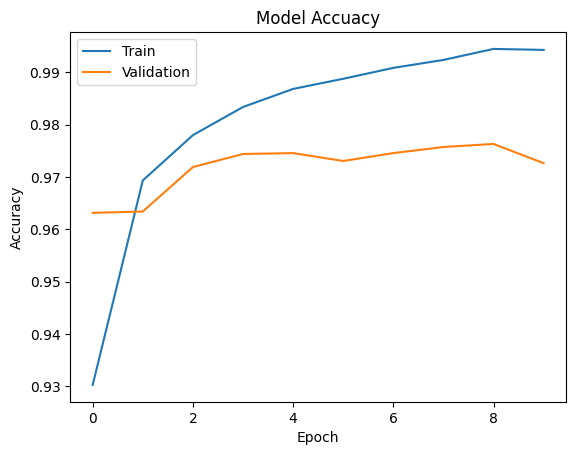

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title("Model Accuacy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

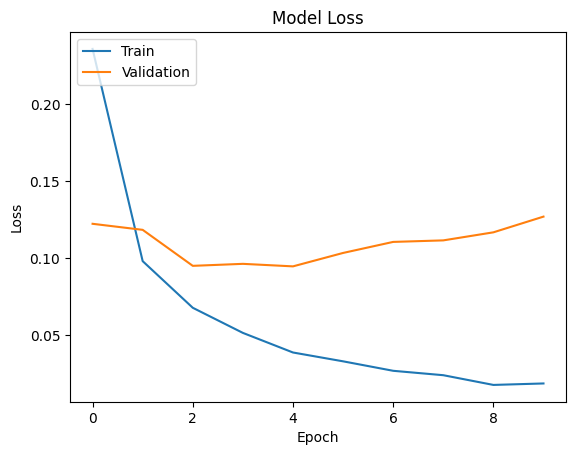

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Tanh


In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='tanh', kernel_initializer='glorot_uniform'))
model.add(Dense(256, activation='tanh', kernel_initializer='glorot_uniform'))
model.add(Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,074 (531.54 KB)

 Trainable params: 136,074 (531.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.optimizers import SGD
opt = SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7312 - loss: 1.0089 - val_accuracy: 0.9003 - val_loss: 0.3497
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9004 - loss: 0.3528 - val_accuracy: 0.9153 - val_loss: 0.2964
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9131 - loss: 0.3042 - val_accuracy: 0.9227 - val_loss: 0.2723
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9231 - loss: 0.2712 - val_accuracy: 0.9274 - val_loss: 0.2532
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9277 - loss: 0.2546 - val_accuracy: 0.9324 - val_loss: 0.2354
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9346 - loss: 0.2275 - val_accuracy: 0.9387 - val_loss: 0.2203
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9370 - loss: 0.2205 - val_accuracy: 0.9422 - val_loss: 0.2064
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9435 - loss: 0.1981 

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9424 - loss: 0.1989


[0.17146404087543488, 0.9513000249862671]

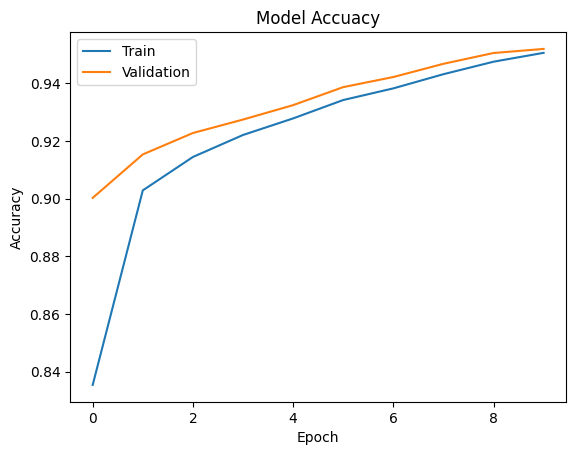

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title("Model Accuacy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

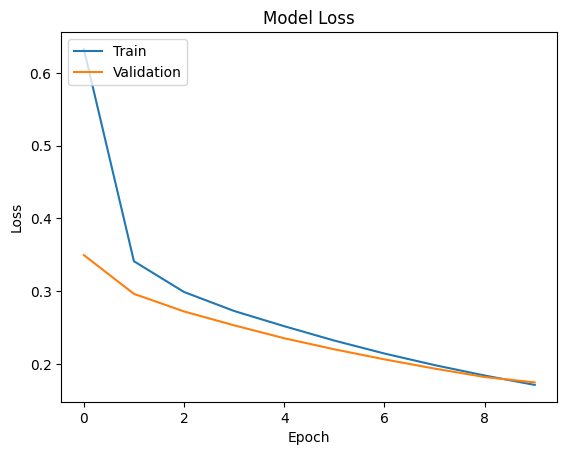

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Varying neurons

In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(64, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hist = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8513 - loss: 0.5136 - val_accuracy: 0.9561 - val_loss: 0.1463
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9599 - loss: 0.1288 - val_accuracy: 0.9668 - val_loss: 0.1114
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9730 - loss: 0.0871 - val_accuracy: 0.9680 - val_loss: 0.1060
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9790 - loss: 0.0689 - val_accuracy: 0.9705 - val_loss: 0.0984
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9850 - loss: 0.0493 - val_accuracy: 0.9698 - val_loss: 0.1014
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9872 - loss: 0.0401 - val_accuracy: 0.9701 - val_loss: 0.1010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9879 - loss: 0.0362 - val_accuracy: 0.9680 - val_loss: 0.1160
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0286 - 

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9678 - loss: 0.1216


[0.1016637459397316, 0.9732000231742859]

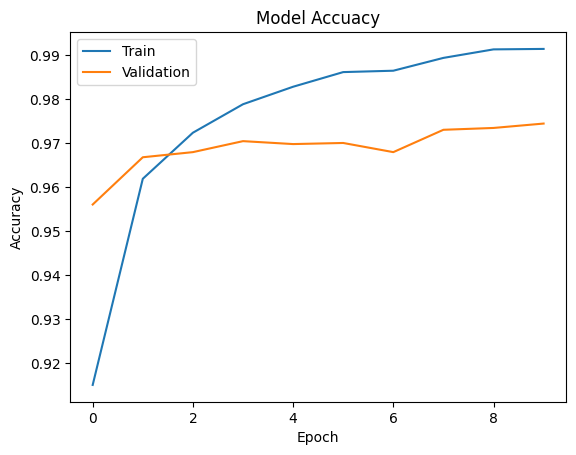

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title("Model Accuacy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

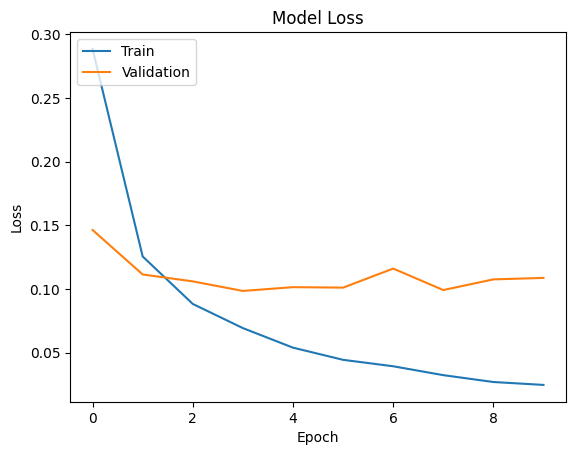

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Changing optimizer

In [ ]:
from keras.optimizers import SGD
opt = SGD(learning_rate=0.01, momentum=0.9)

model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(256, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
hist = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8457 - loss: 0.4962 - val_accuracy: 0.9557 - val_loss: 0.1523
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9619 - loss: 0.1271 - val_accuracy: 0.9656 - val_loss: 0.1130
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0780 - val_accuracy: 0.9653 - val_loss: 0.1171
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9806 - loss: 0.0632 - val_accuracy: 0.9725 - val_loss: 0.0903
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9865 - loss: 0.0441 - val_accuracy: 0.9698 - val_loss: 0.1008
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9877 - loss: 0.0386 - val_accuracy: 0.9750 - val_loss: 0.0890
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9917 - loss: 0.0286 - val_accuracy: 0.9754 - val_loss: 0.0842
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9935 - loss: 0.0217 -

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9755 - loss: 0.0844


[0.07125796377658844, 0.9797000288963318]

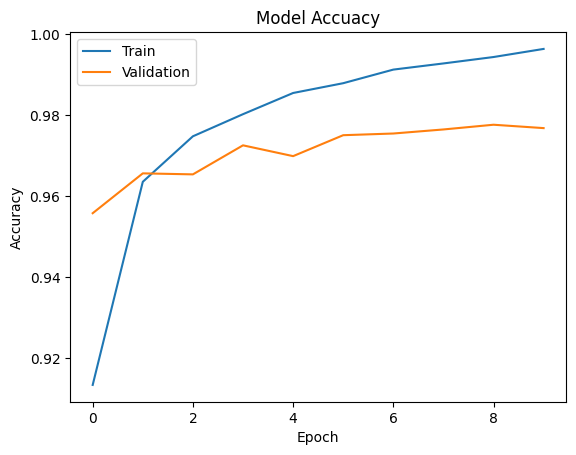

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title("Model Accuacy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

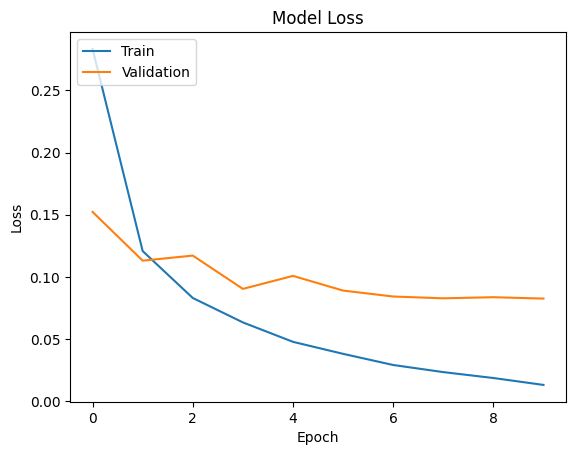

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("best_mnist_model.h5", monitor='val_accuracy', save_best_only=True, mode='max')

hist = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2, callbacks=[checkpoint])

# Load best model
from keras.models import load_model
best_model = load_model("best_mnist_model.h5")
best_model.evaluate(x_test, y_test)


Epoch 1/10
1483/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - loss: 0.0076

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9982 - loss: 0.0076 - val_accuracy: 0.9781 - val_loss: 0.0836
Epoch 2/10
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9986 - loss: 0.0065

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9986 - loss: 0.0065 - val_accuracy: 0.9794 - val_loss: 0.0811
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 0.9793 - val_loss: 0.0864
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9793 - val_loss: 0.0843
Epoch 5/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.0022

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9998 - loss: 0.0022 - val_accuracy: 0.9804 - val_loss: 0.0843
Epoch 6/10
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9999 - loss: 0.0017

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9999 - loss: 0.0017 - val_accuracy: 0.9805 - val_loss: 0.0848
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9798 - val_loss: 0.0862
Epoch 8/10
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0011

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9807 - val_loss: 0.0871
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 8.9804e-04 - val_accuracy: 0.9806 - val_loss: 0.0876
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 1.0000 - loss: 7.9988e-04 - val_accuracy: 0.9807 - val_loss: 0.0887


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9788 - loss: 0.0859


[0.07426963746547699, 0.9818000197410583]